# Lab 2

##Instructions:


*   Fill out the group member names.
*   Make sure that all your responses are provided AS COMMENTS in code boxes. Answers that are not written as comments will be overlooked.
* Ensure that your code is well structured. The quality of your code will be factored into your grade. As such, ensure your code is neatly presented and intuitive.
* Your work MUST be submitted before the slot closes.


# Group Member Names
1. Ben Riak Changdar
2. Daniel Kwasi Kpatamia
3. Kur Malual
4. Matthew Tuurozeeng
5. Inares Tsangue



# Prompt Library
## Prompts we used for this assignment include:
e.q Question number - prompt

CS361 – Introduction to Modeling and Simulation
Laboratory Work – Week 2
Total Marks: 40

Exercise 1 (10 pts)
1. In a Markdown cell, write what error you expect when misspelling a state attribute (e.g., state.wellesely instead of state.wellesley). Include:
•	- The exception type.
•	- Why the error occurs.
2. Actually misspell the attribute and run it. Paste or screenshot the exact error message produced.
3. Explain the meaning of “attribute” in this context (i.e., Python object attribute vs. model state variable terminology). (1 pt)
4. In 1–2 sentences, explain how this helps debug state models. (1 pt)
5. Write a helper function has_state(state, name) that safely checks if a state variable exists. (3 pts)
6. Use it to guard a read or write (e.g., only read state.wellesley if has_state(state, 'wellesley') is True; otherwise print a helpful message). (3 pts)
7. Add asserts for the guard function and show they pass. (2 pts)
Exercise 2 (5 pts)
1. Create a State object with three attributes (e.g., wellesley, framingham, downtown = 0) and display it. (2 pts)
2. Write a helper show_state(state) that prints attributes alphabetically sorted with values, for example:
downtown: 0
framingham: 15
wellesley: 10
You may use vars(state) or state.__dict__. (3 pts)
Exercise 3 (10 pts)
1. Wrap the code in the chapter in a function named run_simulation that takes three parameters: p1, p2, and num_steps. (5 pts)
The function should:
•	- Create a TimeSeries object to hold the results.
•	- Use a for loop to run step the number of times specified by num_steps, passing along p1 and p2.
•	- After each step, save the number of bikes at Olin in the TimeSeries.
•	- After the loop, plot the results.
•	- Decorate the axes.
2. Create a State object with the initial state of the system. (2 pts)
3. Call run_simulation with parameters p1 = 0.3, p2 = 0.2, and num_steps = 60. (3 pts)
Exercise 4 (5 pts)
1. Create a new State object with an additional state variable clock initialized to 0. (3 pts)
2. Write a modified version of step that adds one to the clock each time it is invoked. (2 pts)
3. Test your code by running the simulation and check the value of clock at the end.
Exercise 5 (10 pts)
1. Create a new State object with an additional state variable t_first_empty initialized to -1 to indicate it has not been set. (3 pts)
2. Write a modified version of step that checks whether olin_empty and wellesley_empty are not zero. If a failure occurs, set t_first_empty = clock, but only if t_first_empty has not already been set. (5 pts)
3. Test your code by running the simulation and printing the values of olin_empty, wellesley_empty, and t_first_empty at the end. (2 pts)

# Starter Code

In [ ]:
# install Pint if necessary

try:
    import pint
except ImportError:
    !pip install pint

In [ ]:
# download modsim.py if necessary

from os.path import basename, exists

def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve
        local, _ = urlretrieve(url, filename)
        print('Downloaded ' + local)

download('https://raw.githubusercontent.com/AllenDowney/' +
         'ModSimPy/master/modsim.py')

In [ ]:
# import functions from modsim

from modsim import *

In [ ]:
# Dumnmy bike share
bikeshare = State(olin=10, wellesley=2)

# this line sets the random number generator so the results in
# the book are the same every time we run it
np.random.seed(17)

# Defining functions
def bike_to_wellesley():
  """Move a bike to wellesley"""
  print('Moving a bike to Wellesley')
  bikeshare.olin -= 1
  bikeshare.wellesley += 1


def bike_to_olin():
  """Move a bike to Olin"""
  print('Moving a bike to Olin')
  bikeshare.wellesley -= 1
  bikeshare.olin += 1

def step(p1, p2):
  """Simulate a step"""
  if flip(p1):
    bike_to_wellesley()

  if flip(p2):
    bike_to_olin()

# How flip works
# The usage below produces true with a probability of 70%
# If you run flip like this 100 times, you should get True about 70 times and False about 30 times.
flip(0.7)


# We can simulate a time step like this:
step(0.5,0.5)

# The ModSim library provides a function called show that displays a State object as a table.
show(bikeshare)



Moving a bike to Olin


,state
olin,11
wellesley,1


## Refer to Chapter 2 for info on Time Series & Plotting



---



# Exercise 1 - 10 pts

###Question I

In [ ]:
# Demonstrating the problem of misspelling a state attribute
try:
    print(f"Bikes at Wellesely: {bikeshare.wellesely}")
except AttributeError as e:
    print(f"Error: {e}")
    print("The attribute 'wellesely' doesn't exist - it should be 'wellesley'")

Error: 'Series' object has no attribute 'wellesely'
The attribute 'wellesely' doesn't exist - it should be 'wellesley'


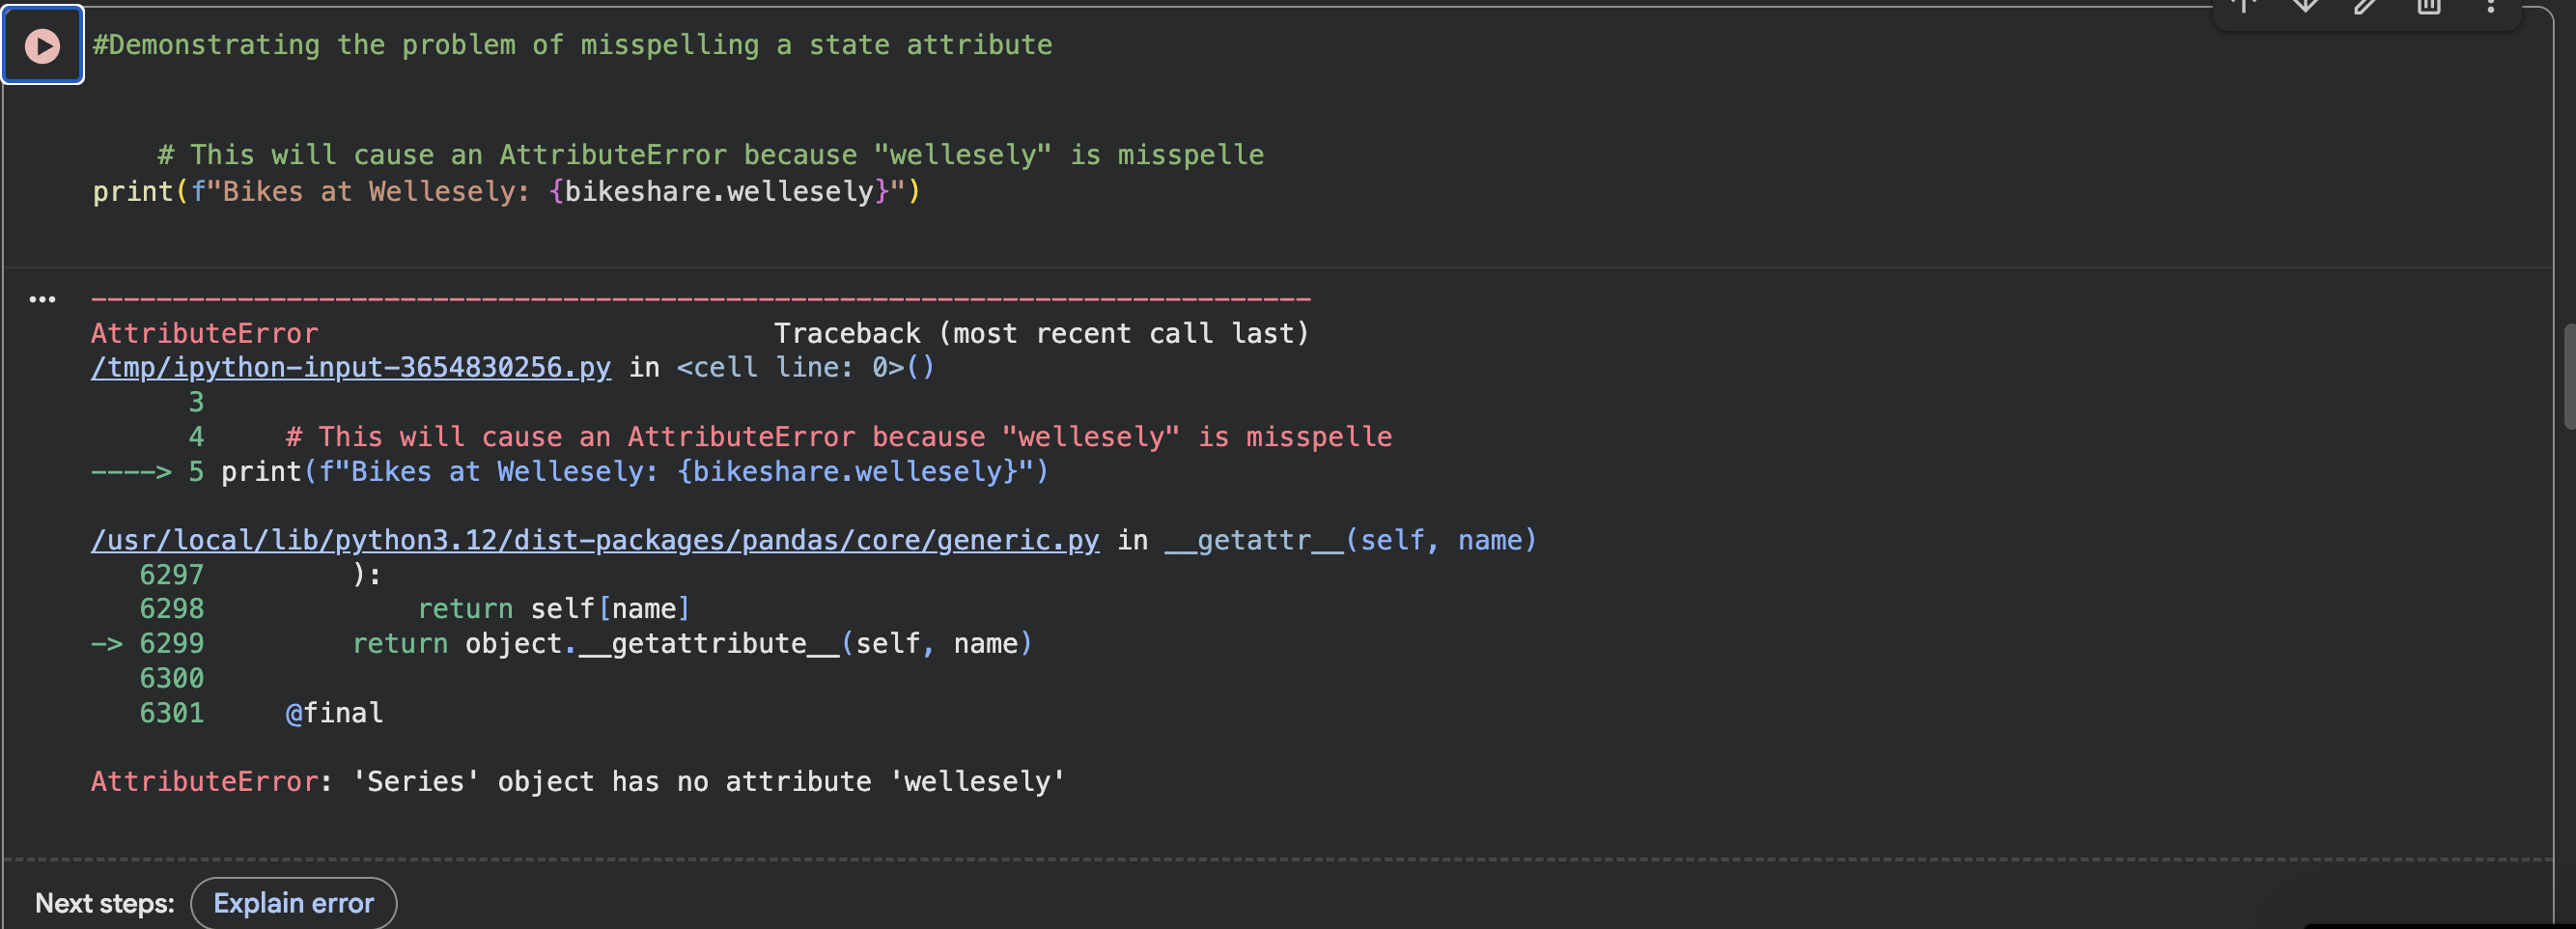

In [ ]:
# Write your answer in this code box
# In Python, an "attribute" is a variable attached to an object (like bikeshare.olin).
# In modeling, these attributes represent the state variables of our system - the values
# that describe the current state of what we're simulating.

###Question II

In [ ]:
# Write your answer in this code box
# Using show() to display the State object helps us see all the state variables and their values
# at a glance, making it easy to spot errors or unexpected values during simulation.

###Question III

In [ ]:
# Write your code exclusively in this code box
def has_state(state, name):
    """Check if a state variable exists in the State object."""
    return hasattr(state, name)

###Question IV

In [ ]:
# Write your code exclusively in this code box
# Example of using the guard function
if has_state(bikeshare, "wellesley"):
    print(f"Bikes at Wellesley: {bikeshare.wellesley}")
else:
    print("Warning: 'wellesley' state variable not found!")

Bikes at Wellesley: 1


###Question IV

In [ ]:
# Write your code exclusively in this code box
# Test that the guard function works correctly
assert has_state(bikeshare, "olin") == True, "Should find 'olin' attribute"
assert has_state(bikeshare, "wellesley") == True, "Should find 'wellesley' attribute"
assert has_state(bikeshare, "nonexistent") == False, "Should not find 'nonexistent' attribute"
print("All assertions passed!")

All assertions passed!




---



# Exercise 2 - 5 pts

###Question a

In [ ]:
# Write your code exclusively in this code box
my_state = State(olin=10, wellesley=12, downtime = 0)
show(my_state)

###Question b

In [ ]:
# Write your code exclusively in this code box
def show_state(state):
    # Get the attributes from the state object
    # modsim.State objects behave like pandas Series, so .items() works
    items = state.items()

    # Sort the items alphabetically by their attribute names (keys)
    sorted_items = sorted(items, key=lambda item: item[0])

    # Print each attribute and its value
    for name, value in sorted_items:
        print(f'{name}: {value}')



---



# Exercise 3 - 10 pts

###Question a

In [ ]:
# Write your code exclusively in this code box
def run_simulation(p1, p2, num_steps):
  results = TimeSeries()
    results[0] = state.olin
  for i in range(num_steps):
      step(state, p1, p2)
      results[i+1] = state.olin


IndentationError: unexpected indent (ipython-input-2029543666.py, line 4)

In [ ]:
bikeshare = State(olin=10, wellesley=2,
                  olin_empty=0, wellesley_empty=0)
results=run_simulation(0.3, 0.2, 60)
show(results)
results.plot(lablel='Olin')
decorate(title='Olin-Wellesley Bikeshare',
             xlabel='Time step (min)',
             ylabel='Number of bikes')



---



# The following questions are based on Chapter 3

# Exercise 4 - 5 pts

###Question I

In [ ]:
# Write your code exclusively in this code box
def make_state_with_clock():
    return State(olin=10, wellesley=2, clock=0)


###Question II

In [ ]:
# Write your code exclusively in this code box
def step_with_clock(state, p1, p2):
    state.clock += 1

    if flip(p1):
        if state.olin > 0:
            bike_to_wellesley(state)

    if flip(p2):
        if state.wellesley > 0:
            bike_to_olin(state)




---



# Exercise 5 - 10 pts

###Question I

In [24]:
# Write your code exclusively in this code box
state = State(olin=10, wellesley=2, clock=0, t_first_empty=-1)

###Question II

In [ ]:
# Write your code exclusively in this code box


###Question III

In [ ]:
# Write your code exclusively in this code box